# Machine Learning - Final Project

---
### Human Activity Recognition Using Smartphones (HAR)


### Project Submission Rules & Requirements
1. **Report:** You must submit a comprehensive PDF report alongside this notebook.
2. **Video Presentation:** A video explaining the logic of your code and demonstrating the outputs for each phase is mandatory.
3. **Naming Convention:** Your submission file must be named exactly as `ML_Project_LastName_StudentID`.
4. **No Late Submissions:** The deadline is strictly enforced.

## Notebook Setup & Imports
In this section, please import all the necessary libraries required for data processing, visualization, dimensionality reduction, clustering, and classification.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Preprocessing and Decomposition
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Supervised Learning
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation Metrics and Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

---
## Phase 1: Exploratory Data Analysis (EDA), Preprocessing & Dimensionality Reduction

### 1.1 Data Loading & EDA
Load the dataset, check for missing values, analyze the distribution of classes, and normalize the features.

In [2]:
def load_data(train_path, test_path):
    """
    Load train and test datasets.

    Parameters:
        train_path (str): Path to training CSV file.
        test_path (str): Path to testing CSV file.

    Returns:
        train_df (DataFrame)
        test_df (DataFrame)
    """

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    print("Train Shape:", train_df.shape)
    print("Test Shape :", test_df.shape)

    return train_df, test_df
def check_missing_values(df):
    """
    Check missing values in a dataframe.
    """

    missing = df.isnull().sum()

    total_missing = missing.sum()

    print("Total Missing Values:", total_missing)

    if total_missing == 0:
        print("No missing values found.")
    else:
        print(missing[missing > 0])
def plot_class_distribution(y):
    """
    Plot class distribution.
    """

    plt.figure(figsize=(8,5))

    sns.countplot(x=y)

    plt.title("Class Distribution")

    plt.xlabel("Activity")

    plt.ylabel("Count")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()
def scale_features(X_train, X_test):
    """
    Standardize feature matrices.
    """

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled
def feature_statistics(df):
    """
    Display statistical summary of numerical features.
    """

    print(df.describe())

In [3]:
train_df, test_df = load_data("train.csv", "test.csv")

Train Shape: (7352, 563)
Test Shape : (2947, 563)


In [4]:
check_missing_values(train_df)
check_missing_values(test_df)

Total Missing Values: 0
No missing values found.
Total Missing Values: 0
No missing values found.


In [5]:
feature_statistics(train_df.drop(columns=["Activity"]))

       tBodyAcc-mean()-X  tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  \
count        7352.000000        7352.000000        7352.000000   
mean            0.274488          -0.017695          -0.109141   
std             0.070261           0.040811           0.056635   
min            -1.000000          -1.000000          -1.000000   
25%             0.262975          -0.024863          -0.120993   
50%             0.277193          -0.017219          -0.108676   
75%             0.288461          -0.010783          -0.097794   
max             1.000000           1.000000           1.000000   

       tBodyAcc-std()-X  tBodyAcc-std()-Y  tBodyAcc-std()-Z  tBodyAcc-mad()-X  \
count       7352.000000       7352.000000       7352.000000       7352.000000   
mean          -0.605438         -0.510938         -0.604754         -0.630512   
std            0.448734          0.502645          0.418687          0.424073   
min           -1.000000         -0.999873         -1.000000         -1.000000   


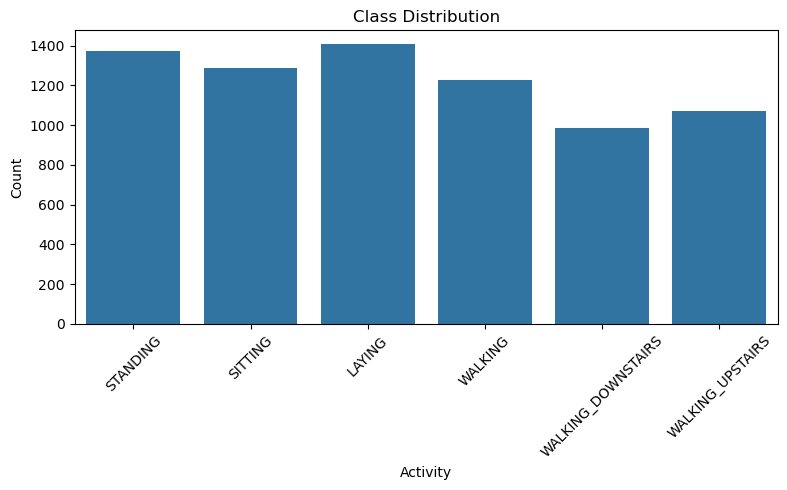

In [6]:
plot_class_distribution(train_df["Activity"])

In [7]:
X_train = train_df.drop(columns=["Activity", "subject"])
y_train = train_df["Activity"]

X_test = test_df.drop(columns=["Activity", "subject"])
y_test = test_df["Activity"]

In [8]:
X_train_scaled, X_test_scaled = scale_features(
    X_train,
    X_test
)

### 1.2 Principal Component Analysis (PCA)
Apply PCA to reduce the feature dimensions from 561 to a smaller set while preserving 95% of the cumulative variance.

In [9]:
def apply_pca(X_train, X_test, variance_threshold=0.95):
    """
    Apply PCA to reduce dimensionality while preserving the desired
    cumulative explained variance.

    Parameters:
        X_train : Scaled training features
        X_test  : Scaled testing features
        variance_threshold : Target cumulative explained variance

    Returns:
        X_train_pca
        X_test_pca
        pca
    """

    # Fit PCA with variance threshold
    pca = PCA(n_components=variance_threshold)

    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Compute cumulative explained variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # Plot
    plt.figure(figsize=(8,5))
    plt.plot(
        range(1, len(cumulative_variance)+1),
        cumulative_variance,
        marker='o'
    )

    plt.axhline(
        y=variance_threshold,
        color='r',
        linestyle='--',
        label=f'{int(variance_threshold*100)}% Variance'
    )

    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("PCA Cumulative Explained Variance")
    plt.grid(True)
    plt.legend()

    plt.show()

    print(f"Original number of features: {X_train.shape[1]}")
    print(f"Reduced number of features : {pca.n_components_}")
    print(f"Explained variance retained: {cumulative_variance[-1]:.4f}")

    return X_train_pca, X_test_pca, pca
def save_reduced_data(X_train_pca, X_test_pca, prefix):
    """
    Save PCA-transformed datasets.
    """

    train_df = pd.DataFrame(X_train_pca)
    test_df = pd.DataFrame(X_test_pca)

    train_df.to_csv(f"{prefix}_train.csv", index=False)
    test_df.to_csv(f"{prefix}_test.csv", index=False)

    print("Reduced datasets saved successfully.")

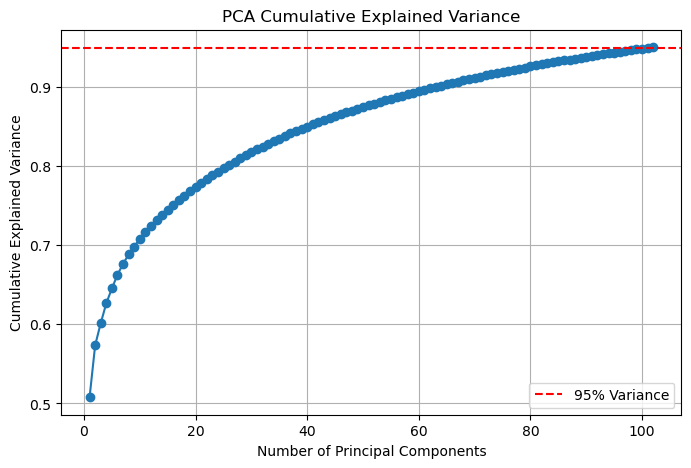

Original number of features: 561
Reduced number of features : 102
Explained variance retained: 0.9508


In [10]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train_scaled,
    X_test_scaled,
    variance_threshold=0.95
)

In [11]:
save_reduced_data(
    X_train_pca,
    X_test_pca,
    prefix="HAR_PCA"
)

Reduced datasets saved successfully.


---
## Phase 2: Unsupervised Learning

### 2.1 K-means Clustering
Implement K-means clustering on the PCA-reduced data. Use the Elbow method to find the optimal number of clusters.

In [12]:
def run_kmeans_elbow(data, max_k=10):
    """
    Plot the Elbow curve to determine the optimal number of clusters.
    """

    inertias = []

    k_values = range(1, max_k + 1)

    for k in k_values:
        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        model.fit(data)

        inertias.append(model.inertia_)

    plt.figure(figsize=(8,5))

    plt.plot(k_values, inertias, marker='o')

    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("Inertia")
    plt.title("Elbow Method for Optimal K")

    plt.grid(True)

    plt.show()

def fit_kmeans(data, n_clusters=6):
    """
    Fit the final K-Means model.
    """

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(data)

    print("K-Means clustering completed.")

    return labels, model

### 2.2 Gaussian Mixture Models (GMM)
Cluster the data using Gaussian Mixture Models optimized via the Expectation-Maximization (EM) algorithm.

In [13]:
def fit_gmm(data, n_components=6):
    """
    Train Gaussian Mixture Model using EM algorithm.
    """

    gmm = GaussianMixture(
        n_components=n_components,
        random_state=42
    )

    labels = gmm.fit_predict(data)

    print("GMM clustering completed.")

    return labels, gmm

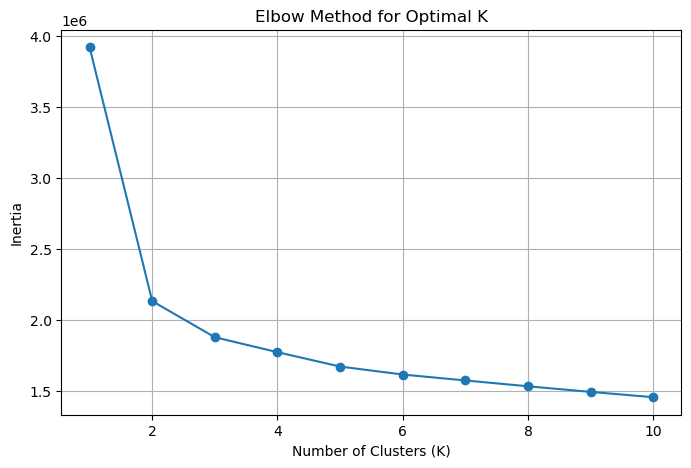

In [14]:
# Run Elbow Method
run_kmeans_elbow(X_train_pca)

In [15]:
# Train K-Means
kmeans_labels, kmeans_model = fit_kmeans(
    X_train_pca,
    n_clusters=6
)

print("Number of clusters:", len(np.unique(kmeans_labels)))

K-Means clustering completed.
Number of clusters: 6


In [16]:
# Train Gaussian Mixture Model
gmm_labels, gmm_model = fit_gmm(
    X_train_pca,
    n_components=6
)

print("Number of clusters:", len(np.unique(gmm_labels)))

GMM clustering completed.
Number of clusters: 6


### 2.3 Clustering Evaluation & Analysis
Compare the results of K-means and GMM. Provide your analytical discussion in the report.

In [17]:
def compare_clustering(y_true, kmeans_labels, gmm_labels):

    kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)
    gmm_ari = adjusted_rand_score(y_true, gmm_labels)

    kmeans_nmi = normalized_mutual_info_score(y_true, kmeans_labels)
    gmm_nmi = normalized_mutual_info_score(y_true, gmm_labels)

    print("=" * 50)
    print("Clustering Evaluation")
    print("=" * 50)

    print(f"K-Means ARI : {kmeans_ari:.4f}")
    print(f"GMM ARI     : {gmm_ari:.4f}")

    print()

    print(f"K-Means NMI : {kmeans_nmi:.4f}")
    print(f"GMM NMI     : {gmm_nmi:.4f}")

    print()

    if kmeans_ari > gmm_ari:
        print("K-Means performs better based on ARI.")
    elif gmm_ari > kmeans_ari:
        print("GMM performs better based on ARI.")
    else:
        print("Both methods perform similarly based on ARI.")

    return {
        "KMeans_ARI": kmeans_ari,
        "GMM_ARI": gmm_ari,
        "KMeans_NMI": kmeans_nmi,
        "GMM_NMI": gmm_nmi
    }

In [18]:
compare_clustering(
    y_train,
    kmeans_labels,
    gmm_labels
)

Clustering Evaluation
K-Means ARI : 0.4196
GMM ARI     : 0.3090

K-Means NMI : 0.5588
GMM NMI     : 0.4905

K-Means performs better based on ARI.


{'KMeans_ARI': 0.41961929313970237,
 'GMM_ARI': 0.3090356896525417,
 'KMeans_NMI': 0.5588203322709341,
 'GMM_NMI': 0.4904857849248058}

---
## Phase 3: Supervised Learning - Classification

### 3.1 Training Base Models
Train the following classifiers using default hyperparameters:  
* Linear & Probabilistic: `Logistic Regression`, `Naive Bayes`  
* Non-parametric: `KNN`, `Decision Tree`  
* Ensemble & Margin-based: `Random Forest`, `SVM`

In [19]:
def train_base_models(X_train, y_train, X_test, y_test):
    """
    Train and evaluate six baseline classification models.
    """

    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Naive Bayes": GaussianNB(),
        "KNN": KNeighborsClassifier(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "SVM": SVC(random_state=42)
    }

    results = {}

    for name, model in models.items():

        # ---------------- Training ----------------
        start_train = time.time()

        model.fit(X_train, y_train)

        train_time = time.time() - start_train

        # ---------------- Testing ----------------
        start_test = time.time()

        predictions = model.predict(X_test)

        test_time = time.time() - start_test

        # ---------------- Metrics ----------------
        accuracy = accuracy_score(y_test, predictions)

        precision = precision_score(
            y_test,
            predictions,
            average="weighted"
        )

        recall = recall_score(
            y_test,
            predictions,
            average="weighted"
        )

        f1 = f1_score(
            y_test,
            predictions,
            average="weighted"
        )

        results[name] = {
            "Model": model,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Train Time (s)": train_time,
            "Test Time (s)": test_time,
            "Predictions": predictions
        }

        print(f"\n{name}")
        print("-" * 40)
        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1 Score : {f1:.4f}")
        print(f"Train Time: {train_time:.4f} s")
        print(f"Test Time : {test_time:.4f} s")

    return results

In [20]:
results = train_base_models(
    X_train_pca,
    y_train,
    X_test_pca,
    y_test
)


Logistic Regression
----------------------------------------
Accuracy : 0.9308
Precision: 0.9313
Recall   : 0.9308
F1 Score : 0.9306
Train Time: 0.2853 s
Test Time : 0.0011 s

Naive Bayes
----------------------------------------
Accuracy : 0.8045
Precision: 0.8116
Recall   : 0.8045
F1 Score : 0.8020
Train Time: 0.0220 s
Test Time : 0.0144 s

KNN
----------------------------------------
Accuracy : 0.8768
Precision: 0.8843
Recall   : 0.8768
F1 Score : 0.8762
Train Time: 0.0076 s
Test Time : 0.0510 s

Decision Tree
----------------------------------------
Accuracy : 0.7533
Precision: 0.7572
Recall   : 0.7533
F1 Score : 0.7543
Train Time: 0.9922 s
Test Time : 0.0011 s

Random Forest
----------------------------------------
Accuracy : 0.8816
Precision: 0.8856
Recall   : 0.8816
F1 Score : 0.8804
Train Time: 7.3520 s
Test Time : 0.0549 s

SVM
----------------------------------------
Accuracy : 0.9376
Precision: 0.9385
Recall   : 0.9376
F1 Score : 0.9374
Train Time: 0.5083 s
Test Time : 0.719

### 3.2 Hyperparameter Tuning
Optimize hyperparameters using Cross-Validation (e.g., Grid Search or Random Search). Compare tuned results with the baseline performance.

In [21]:
def tune_hyperparameters(X_train, y_train):
    """
    Tune Decision Tree and SVM using GridSearchCV.
    """

    # ---------------- Decision Tree ----------------
    dt_params = {
        "max_depth": [5, 10, 15, None],
        "min_samples_split": [2, 5, 10],
        "criterion": ["gini", "entropy"]
    }

    dt_grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        dt_params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    dt_grid.fit(X_train, y_train)

    print("="*50)
    print("Decision Tree Best Parameters")
    print(dt_grid.best_params_)
    print(f"Best CV Accuracy: {dt_grid.best_score_:.4f}")

    # ---------------- SVM ----------------
    svm_params = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }

    svm_grid = GridSearchCV(
        SVC(),
        svm_params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    svm_grid.fit(X_train, y_train)

    print("="*50)
    print("SVM Best Parameters")
    print(svm_grid.best_params_)
    print(f"Best CV Accuracy: {svm_grid.best_score_:.4f}")

    return dt_grid.best_estimator_, svm_grid.best_estimator_

In [22]:
best_dt, best_svm = tune_hyperparameters(
    X_train_pca,
    y_train
)

Decision Tree Best Parameters
{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5}
Best CV Accuracy: 0.7535
SVM Best Parameters
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy: 0.9222


### 3.3 Model Evaluation & Execution Time
Evaluate performance using Accuracy, Precision, Recall, and F1-Score. Measure and record execution time for both training and inference stages.

In [23]:
def evaluate_performance(model, X_test, y_test):
    """
    Evaluate a trained model using standard classification metrics.
    """

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return accuracy, precision, recall, f1

def measure_execution_time(model, X_train, y_train, X_test):
    """
    Measure training and inference time.
    """

    start_train = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_train

    start_test = time.time()

    model.predict(X_test)

    test_time = time.time() - start_test

    print(f"Training Time : {train_time:.4f} s")
    print(f"Testing Time  : {test_time:.4f} s")

    return train_time, test_time

In [24]:
print("Tuned Decision Tree")
evaluate_performance(best_dt, X_test_pca, y_test)

print("\n" + "="*50)

print("Tuned SVM")
evaluate_performance(best_svm, X_test_pca, y_test)

Tuned Decision Tree
Accuracy : 0.7835
Precision: 0.7872
Recall   : 0.7835
F1 Score : 0.7849

Tuned SVM
Accuracy : 0.9410
Precision: 0.9415
Recall   : 0.9410
F1 Score : 0.9408


(0.9409569053274517,
 0.9414651922971465,
 0.9409569053274517,
 0.9407800702277161)

In [25]:
print("Tuned Decision Tree")
measure_execution_time(
    best_dt,
    X_train_pca,
    y_train,
    X_test_pca
)

print("\n" + "="*50)

print("Tuned SVM")
measure_execution_time(
    best_svm,
    X_train_pca,
    y_train,
    X_test_pca
)

Tuned Decision Tree
Training Time : 1.1400 s
Testing Time  : 0.0011 s

Tuned SVM
Training Time : 0.4235 s
Testing Time  : 0.6140 s


(0.42345595359802246, 0.6139640808105469)

### 3.4 Error Analysis & Confusion Matrix
Plot the confusion matrix for the implemented models and identify which classes exhibit the highest classification error.

In [26]:
def plot_confusion_matrix(y_true, y_pred, classes):
    """
    Plot confusion matrix as a heatmap.
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

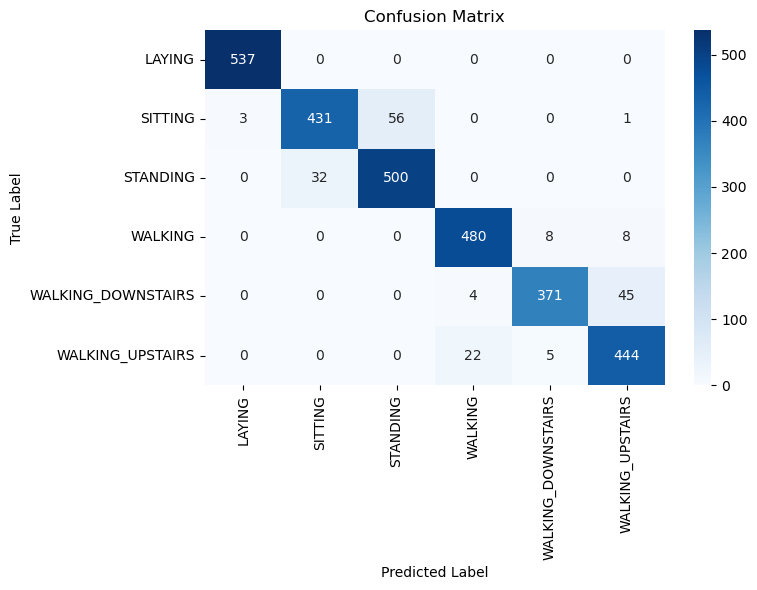

In [27]:
svm_predictions = results["SVM"]["Predictions"]

plot_confusion_matrix(
    y_test,
    svm_predictions,
    classes=np.unique(y_test)
)

Logistic Regression


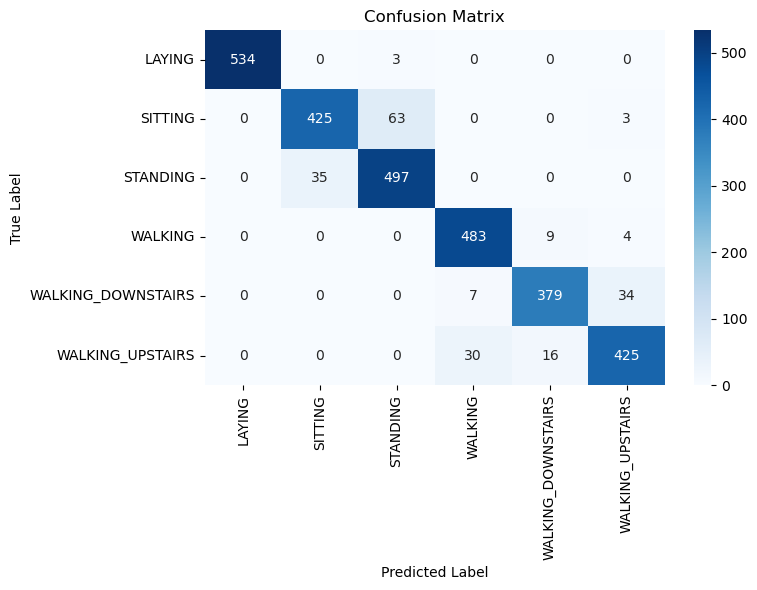

Naive Bayes


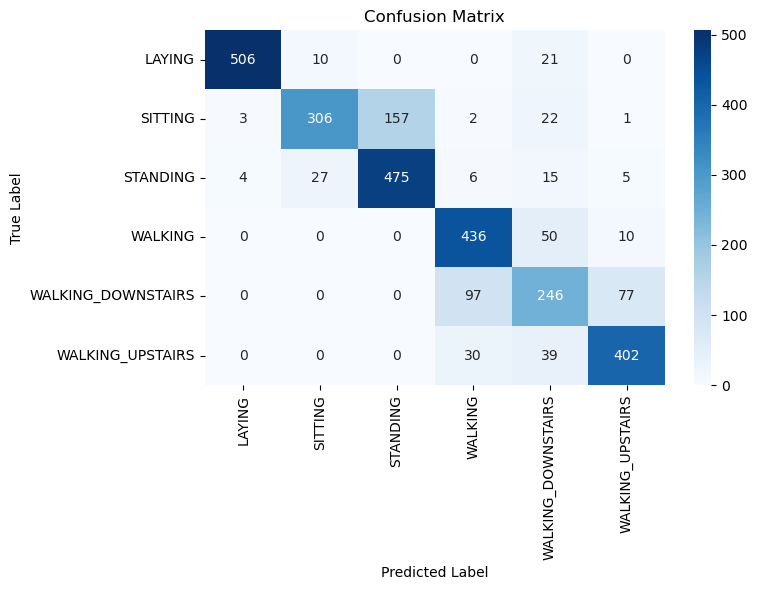

KNN


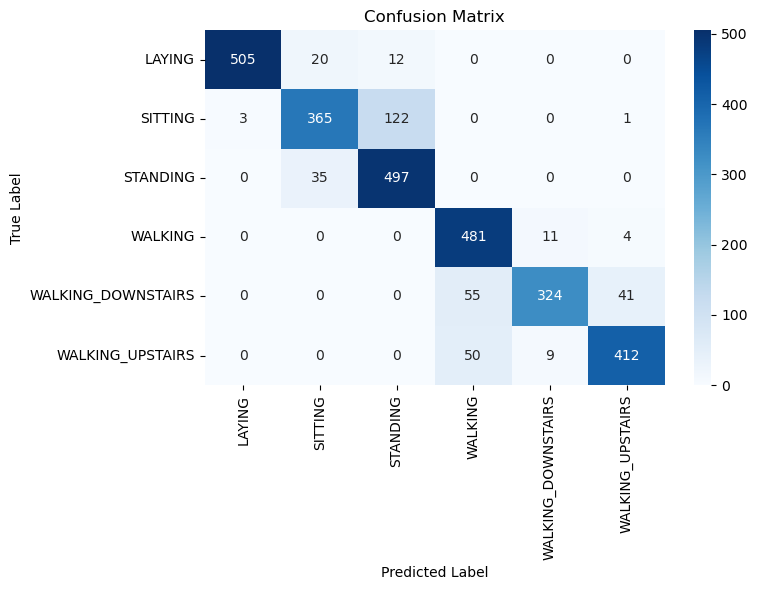

Decision Tree


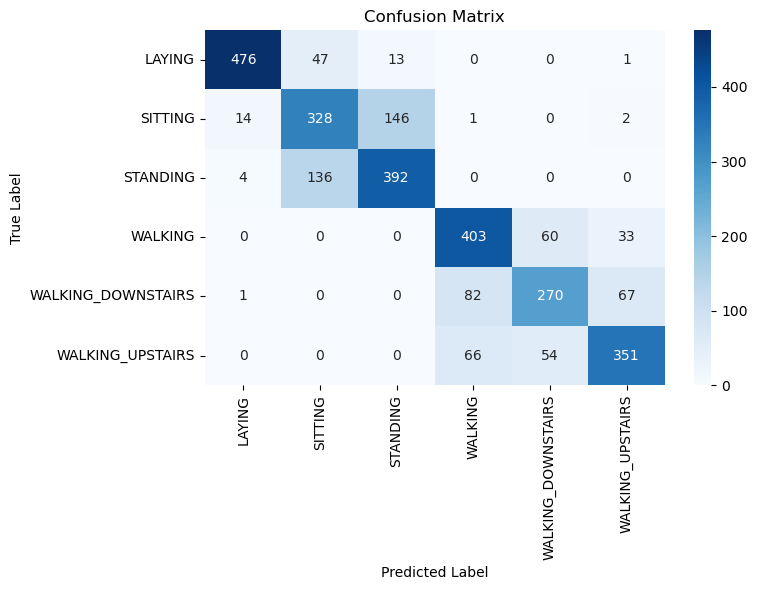

Random Forest


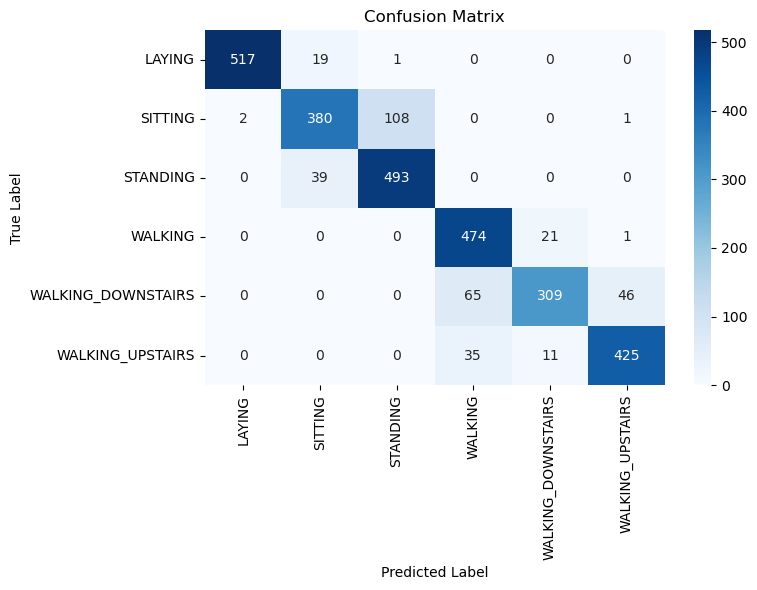

SVM


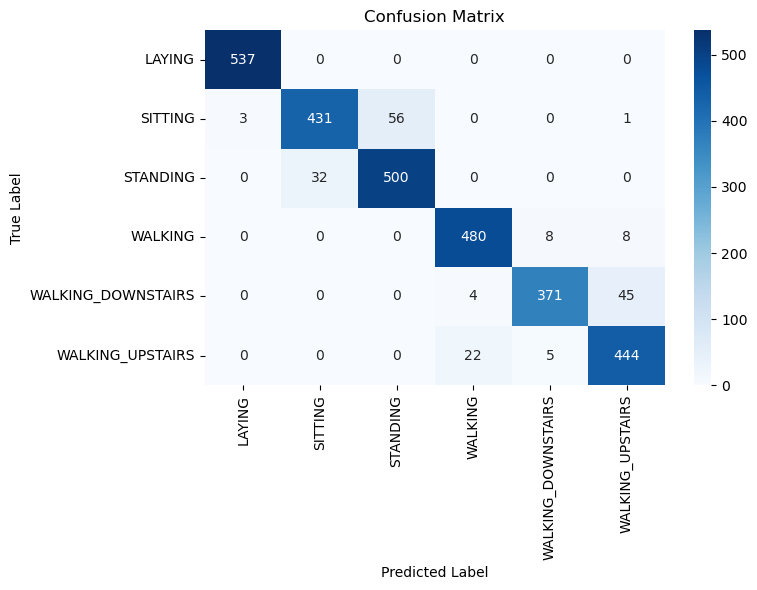

In [28]:
for model_name in results.keys():

    print("="*60)
    print(model_name)
    print("="*60)

    plot_confusion_matrix(
        y_test,
        results[model_name]["Predictions"],
        np.unique(y_test)
    )